In [ ]:
!pip install -q transformers accelerate peft librosa soundfile

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     | 
--------------------------------+------------+-
classifier.out_proj.weight      | UNEXPECTED | 
classifier.out_proj.bias        | UNEXPECTED | 
classifier.dense.bias           | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/peft/config.py:220: UserWarning: Unexpected keyword arguments ['id2label', 'label2id'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved

Loading weights:   0%|          | 0/49 [00:00<?, ?it/s]

HubertModel LOAD REPORT from: BilalHasan/distilhubert-finetuned-ravdess
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
projector.weight  | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 
projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Initiating Inference Phase...


100%|██████████| 345/345 [00:56<00:00,  6.15it/s]



PROPOSED SYSTEM EVALUATION SUMMARY
Weighted Accuracy (WA): 88.99%
Unweighted Accuracy (UA): 89.34%
Macro F1-Score:         0.8861

--- Comparative Analysis vs. MemoCMT (2025) ---
MemoCMT WA: 81.33% | Proposed System: 88.99% (Gain: +7.66%)
MemoCMT UA: 81.50% | Proposed System: 89.34% (Gain: +7.84%)


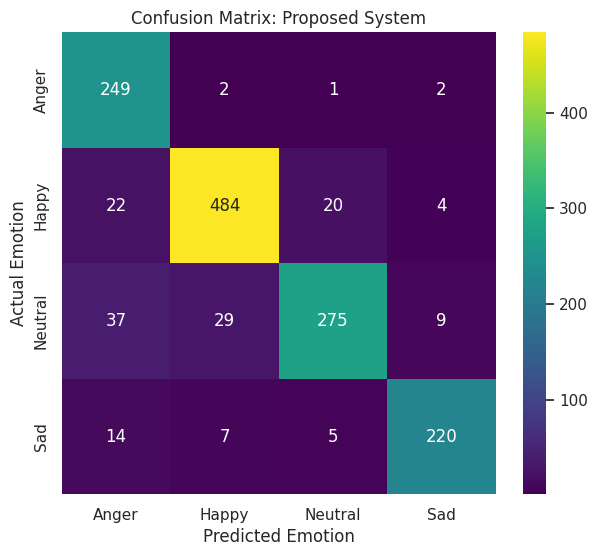

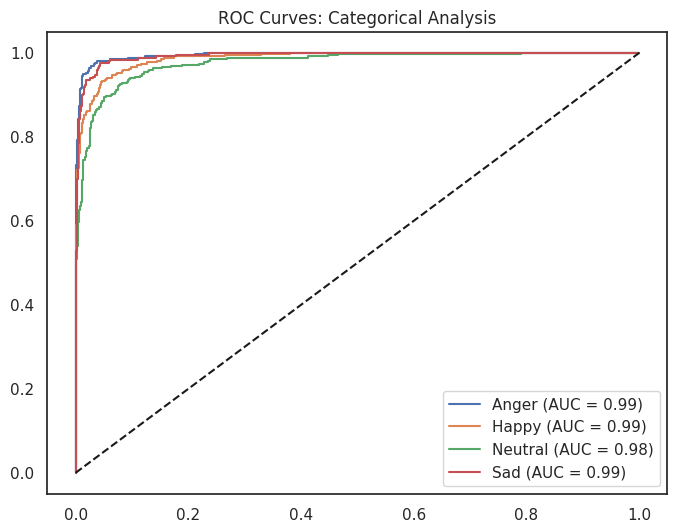

Computing t-SNE embeddings...


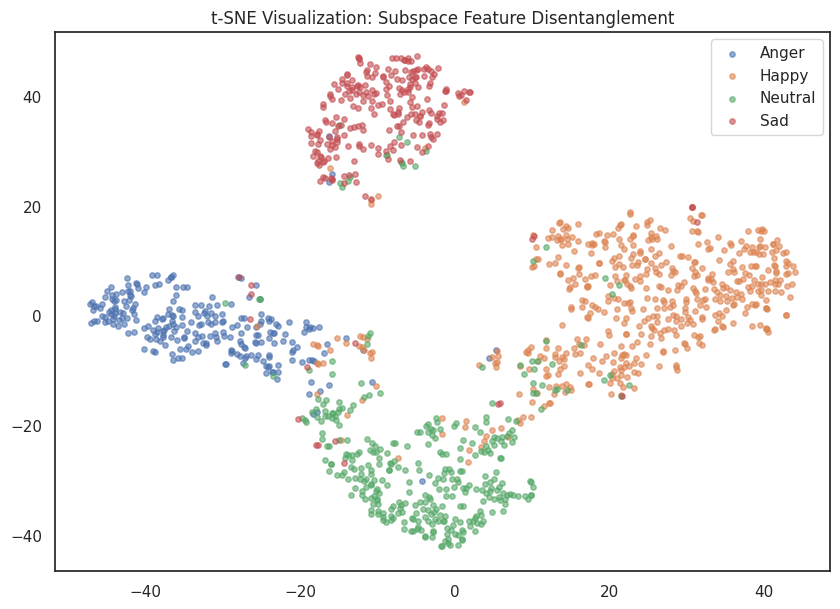

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import io, os, librosa, soundfile as sf, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoFeatureExtractor, AutoModel
from peft import PeftModel
from tqdm import tqdm
from sklearn.manifold import TSNE
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, roc_curve, auc)

# ==========================================
# 1. CONFIGURATION
# ==========================================
class EVAL_CONFIG:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # --- DEFINE PATHS HERE ---
    LORA_PATH = "/content/drive/MyDrive/Final Yr Project Final/LORA Model"
    TEST_PARQUET = "/content/drive/MyDrive/Final Yr Project Final/IEMOCAP 4 Class Test Final.parquet"
    MODEL_PATH = "/content/drive/MyDrive/IEMOCAP 4 Class Folder/Full_MISA_MultiSampe/ms_dropout_fold_4_best_acc.pt"

    BASE_TEXT_MODEL = "j-hartmann/emotion-english-distilroberta-base"
    AUDIO_MODEL_NAME = "BilalHasan/distilhubert-finetuned-ravdess"
    FEAT_DIM = 256
    CLASS_NAMES = ['Anger', 'Happy', 'Neutral', 'Sad']
    LABEL_MAP = {'frustrated': 0, 'angry': 0, 'happy': 1, 'excited': 1, 'neutral': 2, 'sad': 3}

class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Sequential(nn.Linear(dim, dim//2), nn.Tanh(), nn.Linear(dim//2, 1))
    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return torch.sum(x * w, dim=1)

class MultiSampleDropoutHead(nn.Module):
    def __init__(self, feat_dim, num_classes, num_samples=5):
        super().__init__()
        self.dropouts = nn.ModuleList([nn.Dropout(0.5) for _ in range(num_samples)])
        self.classifier = nn.Linear(feat_dim, num_classes)
    def forward(self, x):
        return torch.stack([self.classifier(d(x)) for d in self.dropouts], dim=0).mean(dim=0)

class CrossModalAlignment(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, 8, batch_first=True)
        self.norm = nn.LayerNorm(dim)
    def forward(self, q, kv):
        attn_out, _ = self.attn(q, kv, kv)
        return self.norm(q + attn_out)

class ReliabilityGating(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.gate = nn.Sequential(nn.Linear(dim * 3, 128), nn.GELU(), nn.Linear(128, 3), nn.Softmax(dim=-1))
    def forward(self, pt, s, pa):
        return self.gate(torch.cat([pt, s, pa], dim=-1))

class MISA_GMC_Dropout(nn.Module):
    def __init__(self):
        super().__init__()
        t_base = AutoModel.from_pretrained(EVAL_CONFIG.BASE_TEXT_MODEL)
        self.text_encoder = PeftModel.from_pretrained(t_base, EVAL_CONFIG.LORA_PATH)
        self.audio_encoder = AutoModel.from_pretrained(EVAL_CONFIG.AUDIO_MODEL_NAME)
        self.shared_proj, self.private_t_proj, self.private_a_proj = nn.Linear(768, 256), nn.Linear(768, 256), nn.Linear(768, 256)
        self.alignment, self.gate, self.pool = CrossModalAlignment(256), ReliabilityGating(256), AttentionPooling(256)
        l = nn.TransformerEncoderLayer(d_model=256, nhead=8, batch_first=True)
        self.fusion_transformer = nn.TransformerEncoder(l, num_layers=2)
        self.classifier = MultiSampleDropoutHead(256, 4)

    def forward(self, input_ids, attention_mask, audio_values):
        t_h = self.text_encoder.model(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        a_h = self.audio_encoder(audio_values).last_hidden_state
        st_h, sa_h = self.shared_proj(t_h), self.shared_proj(a_h)
        pt_p, pa_p = self.pool(self.private_t_proj(t_h)), self.pool(self.private_a_proj(a_h))
        s_aligned = self.alignment(st_h, sa_h)
        s_p = self.pool(s_aligned)
        w = self.gate(pt_p, s_p, pa_p)
        h = torch.stack([w[:,0:1]*pt_p, w[:,1:2]*s_p, w[:,2:3]*pa_p], dim=1)
        fused = self.fusion_transformer(h).mean(dim=1)
        return self.classifier(fused), fused

class IEMOCAPTestDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self.tokenizer = AutoTokenizer.from_pretrained(EVAL_CONFIG.LORA_PATH)
        self.feature_extractor = AutoFeatureExtractor.from_pretrained(EVAL_CONFIG.AUDIO_MODEL_NAME)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with io.BytesIO(row['audio']['bytes']) as f: audio, sr = sf.read(f)
        if len(audio.shape) > 1: audio = np.mean(audio, axis=1)
        if sr != 16000: audio = librosa.resample(y=audio, orig_sr=sr, target_sr=16000)
        a_in = self.feature_extractor(audio, sampling_rate=16000, return_tensors="pt", padding='max_length', max_length=160000, truncation=True).input_values.squeeze(0)
        t_in = self.tokenizer(str(row['transcription']), padding='max_length', max_length=128, truncation=True, return_tensors="pt")
        return {'input_ids': t_in['input_ids'].squeeze(0), 'attention_mask': t_in['attention_mask'].squeeze(0), 'audio_values': a_in, 'label': torch.tensor(EVAL_CONFIG.LABEL_MAP[row['major_emotion'].lower()])}

def perform_visual_analysis(all_labels, all_preds, all_probs, all_feats):
    sns.set_theme(style="white")

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=EVAL_CONFIG.CLASS_NAMES, yticklabels=EVAL_CONFIG.CLASS_NAMES)
    plt.title("Confusion Matrix: Proposed System")
    plt.ylabel("Actual Emotion")
    plt.xlabel("Predicted Emotion")
    plt.show()
    plt.figure(figsize=(8, 6))
    for i in range(len(EVAL_CONFIG.CLASS_NAMES)):
        fpr, tpr, _ = roc_curve(all_labels == i, all_probs[:, i])
        plt.plot(fpr, tpr, label=f'{EVAL_CONFIG.CLASS_NAMES[i]} (AUC = {auc(fpr, tpr):.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title("ROC Curves: Categorical Analysis")
    plt.legend()
    plt.show()

    print("Computing t-SNE embeddings...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    low_dim_feats = tsne.fit_transform(all_feats)
    plt.figure(figsize=(10, 7))
    for i in range(len(EVAL_CONFIG.CLASS_NAMES)):
        indices = np.where(all_labels == i)
        plt.scatter(low_dim_feats[indices, 0], low_dim_feats[indices, 1], label=EVAL_CONFIG.CLASS_NAMES[i], alpha=0.6, s=15)
    plt.title("t-SNE Visualization: Subspace Feature Disentanglement")
    plt.legend()
    plt.show()

def main():
    df = pd.read_parquet(EVAL_CONFIG.TEST_PARQUET)
    df = df[df['major_emotion'].str.lower().isin(EVAL_CONFIG.LABEL_MAP.keys())].copy()
    loader = DataLoader(IEMOCAPTestDataset(df), batch_size=4, shuffle=False)

    proposed_model = MISA_GMC_Dropout().to(EVAL_CONFIG.device)
    proposed_model.load_state_dict(torch.load(EVAL_CONFIG.MODEL_PATH, map_location=EVAL_CONFIG.device))
    proposed_model.eval()

    all_labels, all_preds, all_probs, all_feats = [], [], [], []

    print("Initiating Inference Phase...")
    with torch.no_grad():
        for b in tqdm(loader):
            logits, feats = proposed_model(b['input_ids'].to(EVAL_CONFIG.device),
                                           b['attention_mask'].to(EVAL_CONFIG.device),
                                           b['audio_values'].to(EVAL_CONFIG.device))
            all_labels.extend(b['label'].numpy())
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            all_probs.append(F.softmax(logits, dim=1).cpu().numpy())
            all_feats.append(feats.cpu().numpy())

    all_labels, all_preds = np.array(all_labels), np.array(all_preds)
    all_probs, all_feats = np.concatenate(all_probs), np.concatenate(all_feats)

    # Calculate Results
    wa = accuracy_score(all_labels, all_preds) * 100
    ua = recall_score(all_labels, all_preds, average='macro') * 100
    f1 = f1_score(all_labels, all_preds, average='macro')

    print("\n" + "="*50)
    print("PROPOSED SYSTEM EVALUATION SUMMARY")
    print("="*50)
    print(f"Weighted Accuracy (WA): {wa:.2f}%")
    print(f"Unweighted Accuracy (UA): {ua:.2f}%")
    print(f"Macro F1-Score:         {f1:.4f}")

    # MemoCMT Baseline Logging
    print("\n--- Comparative Analysis vs. MemoCMT (2025) ---")
    print(f"MemoCMT WA: 81.33% | Proposed System: {wa:.2f}% (Gain: +{wa-81.33:.2f}%)")
    print(f"MemoCMT UA: 81.50% | Proposed System: {ua:.2f}% (Gain: +{ua-81.50:.2f}%)")

    # Run Visualizations
    perform_visual_analysis(all_labels, all_preds, all_probs, all_feats)

if __name__ == "__main__":
    # from google.colab import drive
    # drive.mount('/content/drive')
    main()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import io, os, librosa, numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoFeatureExtractor, AutoModel
from peft import PeftModel
from tqdm import tqdm
from sklearn.metrics import recall_score, accuracy_score, f1_score

class EVAL_CONFIG:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    MODEL_DIR = "/content/drive/MyDrive/IEMOCAP 4 Class Folder/Full_MISA_MultiSampe/"
    MODEL_FILES = [
        "ms_dropout_fold_1_best_acc.pt",
        "ms_dropout_fold_2_best_acc.pt",
        "ms_dropout_fold_3_best_acc.pt",
        "ms_dropout_fold_4_best_acc.pt",
        "ms_dropout_fold_5_best_acc.pt"
    ]

    LORA_PATH = "/content/drive/MyDrive/Final Yr Project Final/LORA Model"
    TEST_PARQUET = "/content/drive/MyDrive/IEMOCAP 4 Class Folder/Test 4 Class.parquet"

    BASE_TEXT_MODEL = "j-hartmann/emotion-english-distilroberta-base"
    AUDIO_MODEL_NAME = "BilalHasan/distilhubert-finetuned-ravdess"
    FEAT_DIM = 256
    NUM_CLASSES = 4
    LABEL_MAP = {'frustrated': 0, 'angry': 0, 'happy': 1, 'excited': 1, 'neutral': 2, 'sad': 3}

class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Sequential(nn.Linear(dim, dim//2), nn.Tanh(), nn.Linear(dim//2, 1))
    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return torch.sum(x * w, dim=1)

class MultiSampleDropoutHead(nn.Module):
    def __init__(self, feat_dim, num_classes, num_samples=5):
        super().__init__()
        self.dropouts = nn.ModuleList([nn.Dropout(0.5) for _ in range(num_samples)])
        self.classifier = nn.Linear(feat_dim, num_classes)
    def forward(self, x):
        return torch.stack([self.classifier(d(x)) for d in self.dropouts], dim=0).mean(dim=0)

class CrossModalAlignment(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, 8, batch_first=True)
        self.norm = nn.LayerNorm(dim)
    def forward(self, q, kv):
        attn_out, _ = self.attn(q, kv, kv)
        return self.norm(q + attn_out)

class ReliabilityGating(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.gate = nn.Sequential(nn.Linear(dim * 3, 128), nn.GELU(), nn.Linear(128, 3), nn.Softmax(dim=-1))
    def forward(self, pt, s, pa):
        return self.gate(torch.cat([pt, s, pa], dim=-1))

class MISA_GMC_Dropout(nn.Module):
    def __init__(self):
        super().__init__()
        t_base = AutoModel.from_pretrained(EVAL_CONFIG.BASE_TEXT_MODEL)
        self.text_encoder = PeftModel.from_pretrained(t_base, EVAL_CONFIG.LORA_PATH)
        self.audio_encoder = AutoModel.from_pretrained(EVAL_CONFIG.AUDIO_MODEL_NAME)
        self.shared_proj = nn.Linear(768, 256)
        self.private_t_proj = nn.Linear(768, 256)
        self.private_a_proj = nn.Linear(768, 256)
        self.alignment = CrossModalAlignment(256)
        self.gate = ReliabilityGating(256)
        self.pool = AttentionPooling(256)
        l = nn.TransformerEncoderLayer(d_model=256, nhead=8, batch_first=True)
        self.fusion_transformer = nn.TransformerEncoder(l, num_layers=2)
        self.classifier = MultiSampleDropoutHead(256, 4)

    def forward(self, input_ids, attention_mask, audio_values):
        t_h = self.text_encoder.model(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        a_h = self.audio_encoder(audio_values).last_hidden_state
        st_h, sa_h = self.shared_proj(t_h), self.shared_proj(a_h)
        pt_p, pa_p = self.pool(self.private_t_proj(t_h)), self.pool(self.private_a_proj(a_h))
        s_aligned = self.alignment(st_h, sa_h)
        s_p = self.pool(s_aligned)
        w = self.gate(pt_p, s_p, pa_p)
        h = torch.stack([w[:,0:1]*pt_p, w[:,1:2]*s_p, w[:,2:3]*pa_p], dim=1)
        fused = self.fusion_transformer(h).mean(dim=1)
        return self.classifier(fused)

class IEMOCAPTestDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self.tokenizer = AutoTokenizer.from_pretrained(EVAL_CONFIG.LORA_PATH)
        self.feature_extractor = AutoFeatureExtractor.from_pretrained(EVAL_CONFIG.AUDIO_MODEL_NAME)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with io.BytesIO(row['audio']['bytes']) as f: audio, sr = librosa.load(f, sr=16000)
        if len(audio.shape) > 1: audio = np.mean(audio, axis=1)
        a_in = self.feature_extractor(audio, sampling_rate=16000, return_tensors="pt", padding='max_length', max_length=160000, truncation=True).input_values.squeeze(0)
        t_in = self.tokenizer(str(row['transcription']), padding='max_length', max_length=128, truncation=True, return_tensors="pt")
        return {'input_ids': t_in['input_ids'].squeeze(0), 'attention_mask': t_in['attention_mask'].squeeze(0), 'audio_values': a_in, 'label': torch.tensor(EVAL_CONFIG.LABEL_MAP[row['major_emotion'].lower()])}

def evaluate_all_folds():
    # Load test data
    df = pd.read_parquet(EVAL_CONFIG.TEST_PARQUET)
    df = df[df['major_emotion'].str.lower().isin(EVAL_CONFIG.LABEL_MAP.keys())].copy()
    test_loader = DataLoader(IEMOCAPTestDataset(df), batch_size=4, shuffle=False)

    fold_results = []
    ensemble_logits = []

    print(f"Commencing evaluation for {len(EVAL_CONFIG.MODEL_FILES)} folds...")

    for fold_idx, model_name in enumerate(EVAL_CONFIG.MODEL_FILES):
        path = os.path.join(EVAL_CONFIG.MODEL_DIR, model_name)
        if not os.path.exists(path):
            print(f"Warning: {model_name} not found. Skipping.")
            continue

        proposed_system = MISA_GMC_Dropout().to(EVAL_CONFIG.device)
        proposed_system.load_state_dict(torch.load(path, map_location=EVAL_CONFIG.device))
        proposed_system.eval()

        fold_preds, fold_labels, fold_raw_logits = [], [], []

        with torch.no_grad():
            for b in tqdm(test_loader, desc=f"Fold {fold_idx+1}", leave=False):
                logits = proposed_system(b['input_ids'].to(EVAL_CONFIG.device),
                                         b['attention_mask'].to(EVAL_CONFIG.device),
                                         b['audio_values'].to(EVAL_CONFIG.device))
                fold_raw_logits.append(logits.cpu().numpy())
                fold_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                fold_labels.extend(b['label'].numpy())

        wa = accuracy_score(fold_labels, fold_preds) * 100
        ua = recall_score(fold_labels, fold_preds, average='macro') * 100
        f1 = f1_score(fold_labels, fold_preds, average='macro')

        fold_results.append({'Fold': fold_idx+1, 'WA (%)': wa, 'UA (%)': ua, 'F1': f1})
        ensemble_logits.append(np.concatenate(fold_raw_logits))

    print("\nCalculating Ensemble Performance...")
    mean_logits = np.mean(ensemble_logits, axis=0)
    ensemble_preds = np.argmax(mean_logits, axis=1)

    e_wa = accuracy_score(fold_labels, ensemble_preds) * 100
    e_ua = recall_score(fold_labels, ensemble_preds, average='macro') * 100
    e_f1 = f1_score(fold_labels, ensemble_preds, average='macro')

    fold_results.append({'Fold': 'ENSEMBLE', 'WA (%)': e_wa, 'UA (%)': e_ua, 'F1': e_f1})

    report_df = pd.DataFrame(fold_results)
    print("\n" + "="*60)
    print("PROPOSED SYSTEM: CROSS-MODAL 5-FOLD COMPARATIVE SUMMARY")
    print("="*60)
    print(report_df.to_string(index=False, float_format=lambda x: "{:.2f}".format(x)))
    print("="*60)

if __name__ == "__main__":

    evaluate_all_folds()

Commencing evaluation for 5 folds...


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     | 
--------------------------------+------------+-
classifier.out_proj.weight      | UNEXPECTED | 
classifier.out_proj.bias        | UNEXPECTED | 
classifier.dense.bias           | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/peft/config.py:220: UserWarning: Unexpected keyword arguments ['id2label', 'label2id'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved

Loading weights:   0%|          | 0/49 [00:00<?, ?it/s]

HubertModel LOAD REPORT from: BilalHasan/distilhubert-finetuned-ravdess
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
projector.weight  | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 
projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     | 
--------------------------------+------------+-
classifier.out_proj.weight      | UNEXPECTED | 
classifier.out_proj.bias        | UNEXPECTED | 
classifier.dense.bias           | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/peft/config.py:220: UserWarning: Unexpected keyword arguments ['id2label', 'label2id'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved

Loading weights:   0%|          | 0/49 [00:00<?, ?it/s]

HubertModel LOAD REPORT from: BilalHasan/distilhubert-finetuned-ravdess
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
projector.weight  | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 
projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Calculating Ensemble Performance...

PROPOSED SYSTEM: CROSS-MODAL 5-FOLD COMPARATIVE SUMMARY
    Fold  WA (%)  UA (%)   F1
       1   81.53   79.99 0.79
       2   85.95   83.79 0.84
       3   83.72   79.73 0.81
       4   86.62   83.64 0.85
       5   83.36   81.69 0.81
ENSEMBLE   86.16   83.58 0.84


In [ ]:
!pip uninstall -y whisper
!pip install openai-whisper

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import numpy as np
import whisper
import os
from transformers import AutoTokenizer, AutoFeatureExtractor, AutoModel
from peft import PeftModel

class INFERENCE_CONFIG:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    MODEL_PATH = "/content/drive/MyDrive/IEMOCAP 4 Class Folder/Full_MISA_MultiSampe/ms_dropout_fold_4_best_acc.pt"
    LORA_PATH = "/content/drive/MyDrive/Final Yr Project Final/LORA Model"

    BASE_TEXT_MODEL = "j-hartmann/emotion-english-distilroberta-base"
    AUDIO_MODEL_NAME = "BilalHasan/distilhubert-finetuned-ravdess"

    FEAT_DIM = 256
    CLASS_NAMES = ['Anger', 'Happy', 'Neutral', 'Sad']

class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Sequential(nn.Linear(dim, dim//2), nn.Tanh(), nn.Linear(dim//2, 1))
    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return torch.sum(x * w, dim=1)

class MultiSampleDropoutHead(nn.Module):
    def __init__(self, feat_dim, num_classes, num_samples=5):
        super().__init__()
        self.dropouts = nn.ModuleList([nn.Dropout(0.5) for _ in range(num_samples)])
        self.classifier = nn.Linear(feat_dim, num_classes)
    def forward(self, x):
        return torch.stack([self.classifier(d(x)) for d in self.dropouts], dim=0).mean(dim=0)

class CrossModalAlignment(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, 8, batch_first=True)
        self.norm = nn.LayerNorm(dim)
    def forward(self, q, kv):
        attn_out, _ = self.attn(q, kv, kv)
        return self.norm(q + attn_out)

class ReliabilityGating(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.gate = nn.Sequential(nn.Linear(dim * 3, 128), nn.GELU(), nn.Linear(128, 3), nn.Softmax(dim=-1))
    def forward(self, pt, s, pa):
        return self.gate(torch.cat([pt, s, pa], dim=-1))

class MISA_GMC_Inference_Model(nn.Module):
    def __init__(self):
        super().__init__()
        t_base = AutoModel.from_pretrained(INFERENCE_CONFIG.BASE_TEXT_MODEL)
        self.text_encoder = PeftModel.from_pretrained(t_base, INFERENCE_CONFIG.LORA_PATH)
        self.audio_encoder = AutoModel.from_pretrained(INFERENCE_CONFIG.AUDIO_MODEL_NAME)
        self.shared_proj, self.private_t_proj, self.private_a_proj = nn.Linear(768, 256), nn.Linear(768, 256), nn.Linear(768, 256)
        self.alignment, self.gate, self.pool = CrossModalAlignment(256), ReliabilityGating(256), AttentionPooling(256)
        l = nn.TransformerEncoderLayer(d_model=256, nhead=8, batch_first=True)
        self.fusion_transformer = nn.TransformerEncoder(l, num_layers=2)
        self.classifier = MultiSampleDropoutHead(256, 4)

    def forward(self, input_ids, attention_mask, audio_values):
        t_h = self.text_encoder.model(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        a_h = self.audio_encoder(audio_values).last_hidden_state
        st_h, sa_h = self.shared_proj(t_h), self.shared_proj(a_h)
        pt_p, pa_p = self.pool(self.private_t_proj(t_h)), self.pool(self.private_a_proj(a_h))
        s_aligned = self.alignment(st_h, sa_h)
        s_p = self.pool(s_aligned)
        w = self.gate(pt_p, s_p, pa_p)
        h = torch.stack([w[:,0:1]*pt_p, w[:,1:2]*s_p, w[:,2:3]*pa_p], dim=1)
        fused = self.fusion_transformer(h).mean(dim=1)
        return self.classifier(fused)

def test_custom_audio(audio_file_path):
    print(f"--- Processing File: {os.path.basename(audio_file_path)} ---")

    audio_16k, _ = librosa.load(audio_file_path, sr=16000)
    if len(audio_16k.shape) > 1: audio_16k = np.mean(audio_16k, axis=1)

    print("--- Extracting Transcript via Whisper ---")
    whisper_model = whisper.load_model("base").to(INFERENCE_CONFIG.device)
    result = whisper_model.transcribe(audio_file_path)
    transcript = result['text'].strip()
    print(f"TRANSCRIPT: \"{transcript}\"")

    tokenizer = AutoTokenizer.from_pretrained(INFERENCE_CONFIG.LORA_PATH)
    proposed_system = MISA_GMC_Inference_Model().to(INFERENCE_CONFIG.device)
    proposed_system.load_state_dict(torch.load(INFERENCE_CONFIG.MODEL_PATH, map_location=INFERENCE_CONFIG.device))
    proposed_system.eval()

    t_in = tokenizer(transcript, padding='max_length', max_length=128, truncation=True, return_tensors="pt")

    max_samples = 160000
    if len(audio_16k) < max_samples:
        audio_padded = np.pad(audio_16k, (0, max_samples - len(audio_16k)), 'constant')
    else:
        audio_padded = audio_16k[:max_samples]

    audio_tensor = torch.from_numpy(audio_padded).float()
    audio_norm = (audio_tensor - audio_tensor.mean()) / torch.sqrt(audio_tensor.var() + 1e-7)
    audio_values = audio_norm.unsqueeze(0).to(INFERENCE_CONFIG.device)

    with torch.no_grad():
        logits = proposed_system(t_in['input_ids'].to(INFERENCE_CONFIG.device),
                                 t_in['attention_mask'].to(INFERENCE_CONFIG.device),
                                 audio_values)

        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        pred_idx = np.argmax(probs)

    print("\n" + "="*40)
    print("PROPOSED SYSTEM: CUSTOM INFERENCE RESULTS")
    print("="*40)
    print(f"PREDICTED EMOTION: {INFERENCE_CONFIG.CLASS_NAMES[pred_idx]}")
    print(f"MAJOR PROBABILITY: {probs[pred_idx]*100:.2f}%")
    print("-" * 40)
    for i, name in enumerate(INFERENCE_CONFIG.CLASS_NAMES):
        print(f"{name:10}: {probs[i]*100:.2f}%")
    print("="*40)
if __name__ == "__main__":
    custom_audio_path = "/content/Angry.wav"

    if os.path.exists(custom_audio_path):
        test_custom_audio(custom_audio_path)
    else:
        print(f"Error: File {custom_audio_path} not found.")

--- Processing File: Angry.wav ---
--- Extracting Transcript via Whisper ---


100%|███████████████████████████████████████| 139M/139M [00:02<00:00, 53.6MiB/s]


TRANSCRIPT: "Yeah, you want to see my supervisor huh? Yeah, you want to see my supervisor fine. I'll be right back"


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     | 
--------------------------------+------------+-
classifier.out_proj.weight      | UNEXPECTED | 
classifier.out_proj.bias        | UNEXPECTED | 
classifier.dense.bias           | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/peft/config.py:220: UserWarning: Unexpected keyword arguments ['id2label', 'label2id'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved

Loading weights:   0%|          | 0/49 [00:00<?, ?it/s]

HubertModel LOAD REPORT from: BilalHasan/distilhubert-finetuned-ravdess
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
projector.weight  | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 
projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



PROPOSED SYSTEM: CUSTOM INFERENCE RESULTS
PREDICTED EMOTION: Anger
MAJOR PROBABILITY: 94.74%
----------------------------------------
Anger     : 94.74%
Happy     : 1.66%
Neutral   : 1.48%
Sad       : 2.12%


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import numpy as np
import whisper
import os
from transformers import AutoTokenizer, AutoFeatureExtractor, AutoModel
from peft import PeftModel

class INFERENCE_CONFIG:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    MODEL_PATH = "/content/drive/MyDrive/IEMOCAP 4 Class Folder/Full_MISA_MultiSampe/ms_dropout_fold_4_best_acc.pt"
    LORA_PATH = "/content/drive/MyDrive/Final Yr Project Final/LORA Model"

    BASE_TEXT_MODEL = "j-hartmann/emotion-english-distilroberta-base"
    AUDIO_MODEL_NAME = "BilalHasan/distilhubert-finetuned-ravdess"

    FEAT_DIM = 256
    CLASS_NAMES = ['Anger', 'Happy', 'Neutral', 'Sad']

class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Sequential(nn.Linear(dim, dim//2), nn.Tanh(), nn.Linear(dim//2, 1))
    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return torch.sum(x * w, dim=1)

class MultiSampleDropoutHead(nn.Module):
    def __init__(self, feat_dim, num_classes, num_samples=5):
        super().__init__()
        self.dropouts = nn.ModuleList([nn.Dropout(0.5) for _ in range(num_samples)])
        self.classifier = nn.Linear(feat_dim, num_classes)
    def forward(self, x):
        return torch.stack([self.classifier(d(x)) for d in self.dropouts], dim=0).mean(dim=0)

class CrossModalAlignment(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, 8, batch_first=True)
        self.norm = nn.LayerNorm(dim)
    def forward(self, q, kv):
        attn_out, _ = self.attn(q, kv, kv)
        return self.norm(q + attn_out)

class ReliabilityGating(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.gate = nn.Sequential(nn.Linear(dim * 3, 128), nn.GELU(), nn.Linear(128, 3), nn.Softmax(dim=-1))
    def forward(self, pt, s, pa):
        return self.gate(torch.cat([pt, s, pa], dim=-1))

class MISA_GMC_Inference_Model(nn.Module):
    def __init__(self):
        super().__init__()
        t_base = AutoModel.from_pretrained(INFERENCE_CONFIG.BASE_TEXT_MODEL)
        self.text_encoder = PeftModel.from_pretrained(t_base, INFERENCE_CONFIG.LORA_PATH)
        self.audio_encoder = AutoModel.from_pretrained(INFERENCE_CONFIG.AUDIO_MODEL_NAME)
        self.shared_proj, self.private_t_proj, self.private_a_proj = nn.Linear(768, 256), nn.Linear(768, 256), nn.Linear(768, 256)
        self.alignment, self.gate, self.pool = CrossModalAlignment(256), ReliabilityGating(256), AttentionPooling(256)
        l = nn.TransformerEncoderLayer(d_model=256, nhead=8, batch_first=True)
        self.fusion_transformer = nn.TransformerEncoder(l, num_layers=2)
        self.classifier = MultiSampleDropoutHead(256, 4)

    def forward(self, input_ids, attention_mask, audio_values):
        t_h = self.text_encoder.model(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        a_h = self.audio_encoder(audio_values).last_hidden_state
        st_h, sa_h = self.shared_proj(t_h), self.shared_proj(a_h)
        pt_p, pa_p = self.pool(self.private_t_proj(t_h)), self.pool(self.private_a_proj(a_h))
        s_aligned = self.alignment(st_h, sa_h)
        s_p = self.pool(s_aligned)
        w = self.gate(pt_p, s_p, pa_p)
        h = torch.stack([w[:,0:1]*pt_p, w[:,1:2]*s_p, w[:,2:3]*pa_p], dim=1)
        fused = self.fusion_transformer(h).mean(dim=1)
        return self.classifier(fused)

def test_custom_audio(audio_file_path):
    print(f"--- Processing File: {os.path.basename(audio_file_path)} ---")

    audio_16k, _ = librosa.load(audio_file_path, sr=16000)
    if len(audio_16k.shape) > 1: audio_16k = np.mean(audio_16k, axis=1)

    print("--- Extracting Transcript via Whisper ---")
    whisper_model = whisper.load_model("base").to(INFERENCE_CONFIG.device)
    result = whisper_model.transcribe(audio_file_path)
    transcript = result['text'].strip()
    print(f"TRANSCRIPT: \"{transcript}\"")

    tokenizer = AutoTokenizer.from_pretrained(INFERENCE_CONFIG.LORA_PATH)
    proposed_system = MISA_GMC_Inference_Model().to(INFERENCE_CONFIG.device)
    proposed_system.load_state_dict(torch.load(INFERENCE_CONFIG.MODEL_PATH, map_location=INFERENCE_CONFIG.device))
    proposed_system.eval()

    t_in = tokenizer(transcript, padding='max_length', max_length=128, truncation=True, return_tensors="pt")

    max_samples = 160000
    if len(audio_16k) < max_samples:
        audio_padded = np.pad(audio_16k, (0, max_samples - len(audio_16k)), 'constant')
    else:
        audio_padded = audio_16k[:max_samples]

    audio_tensor = torch.from_numpy(audio_padded).float()
    audio_norm = (audio_tensor - audio_tensor.mean()) / torch.sqrt(audio_tensor.var() + 1e-7)
    audio_values = audio_norm.unsqueeze(0).to(INFERENCE_CONFIG.device)

    with torch.no_grad():
        logits = proposed_system(t_in['input_ids'].to(INFERENCE_CONFIG.device),
                                 t_in['attention_mask'].to(INFERENCE_CONFIG.device),
                                 audio_values)

        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        pred_idx = np.argmax(probs)

    print("\n" + "="*40)
    print("PROPOSED SYSTEM: CUSTOM INFERENCE RESULTS")
    print("="*40)
    print(f"PREDICTED EMOTION: {INFERENCE_CONFIG.CLASS_NAMES[pred_idx]}")
    print(f"MAJOR PROBABILITY: {probs[pred_idx]*100:.2f}%")
    print("-" * 40)
    for i, name in enumerate(INFERENCE_CONFIG.CLASS_NAMES):
        print(f"{name:10}: {probs[i]*100:.2f}%")
    print("="*40)
if __name__ == "__main__":
    custom_audio_path = "/content/Sad.wav"

    if os.path.exists(custom_audio_path):
        test_custom_audio(custom_audio_path)
    else:
        print(f"Error: File {custom_audio_path} not found.")

--- Processing File: Sad.wav ---
--- Extracting Transcript via Whisper ---
TRANSCRIPT: "Did you get the mail? See you somewhere later."


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     | 
--------------------------------+------------+-
classifier.out_proj.weight      | UNEXPECTED | 
classifier.out_proj.bias        | UNEXPECTED | 
classifier.dense.bias           | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/peft/config.py:220: UserWarning: Unexpected keyword arguments ['id2label', 'label2id'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved

Loading weights:   0%|          | 0/49 [00:00<?, ?it/s]

HubertModel LOAD REPORT from: BilalHasan/distilhubert-finetuned-ravdess
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
projector.weight  | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 
projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



PROPOSED SYSTEM: CUSTOM INFERENCE RESULTS
PREDICTED EMOTION: Sad
MAJOR PROBABILITY: 41.53%
----------------------------------------
Anger     : 5.16%
Happy     : 18.79%
Neutral   : 34.52%
Sad       : 41.53%


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import numpy as np
import whisper
import os
from transformers import AutoTokenizer, AutoFeatureExtractor, AutoModel
from peft import PeftModel

class INFERENCE_CONFIG:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    MODEL_PATH = "/content/drive/MyDrive/IEMOCAP 4 Class Folder/Full_MISA_MultiSampe/ms_dropout_fold_4_best_acc.pt"
    LORA_PATH = "/content/drive/MyDrive/Final Yr Project Final/LORA Model"

    BASE_TEXT_MODEL = "j-hartmann/emotion-english-distilroberta-base"
    AUDIO_MODEL_NAME = "BilalHasan/distilhubert-finetuned-ravdess"

    FEAT_DIM = 256
    CLASS_NAMES = ['Anger', 'Happy', 'Neutral', 'Sad']

class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Sequential(nn.Linear(dim, dim//2), nn.Tanh(), nn.Linear(dim//2, 1))
    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return torch.sum(x * w, dim=1)

class MultiSampleDropoutHead(nn.Module):
    def __init__(self, feat_dim, num_classes, num_samples=5):
        super().__init__()
        self.dropouts = nn.ModuleList([nn.Dropout(0.5) for _ in range(num_samples)])
        self.classifier = nn.Linear(feat_dim, num_classes)
    def forward(self, x):
        return torch.stack([self.classifier(d(x)) for d in self.dropouts], dim=0).mean(dim=0)

class CrossModalAlignment(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, 8, batch_first=True)
        self.norm = nn.LayerNorm(dim)
    def forward(self, q, kv):
        attn_out, _ = self.attn(q, kv, kv)
        return self.norm(q + attn_out)

class ReliabilityGating(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.gate = nn.Sequential(nn.Linear(dim * 3, 128), nn.GELU(), nn.Linear(128, 3), nn.Softmax(dim=-1))
    def forward(self, pt, s, pa):
        return self.gate(torch.cat([pt, s, pa], dim=-1))

class MISA_GMC_Inference_Model(nn.Module):
    def __init__(self):
        super().__init__()
        t_base = AutoModel.from_pretrained(INFERENCE_CONFIG.BASE_TEXT_MODEL)
        self.text_encoder = PeftModel.from_pretrained(t_base, INFERENCE_CONFIG.LORA_PATH)
        self.audio_encoder = AutoModel.from_pretrained(INFERENCE_CONFIG.AUDIO_MODEL_NAME)
        self.shared_proj, self.private_t_proj, self.private_a_proj = nn.Linear(768, 256), nn.Linear(768, 256), nn.Linear(768, 256)
        self.alignment, self.gate, self.pool = CrossModalAlignment(256), ReliabilityGating(256), AttentionPooling(256)
        l = nn.TransformerEncoderLayer(d_model=256, nhead=8, batch_first=True)
        self.fusion_transformer = nn.TransformerEncoder(l, num_layers=2)
        self.classifier = MultiSampleDropoutHead(256, 4)

    def forward(self, input_ids, attention_mask, audio_values):
        t_h = self.text_encoder.model(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        a_h = self.audio_encoder(audio_values).last_hidden_state
        st_h, sa_h = self.shared_proj(t_h), self.shared_proj(a_h)
        pt_p, pa_p = self.pool(self.private_t_proj(t_h)), self.pool(self.private_a_proj(a_h))
        s_aligned = self.alignment(st_h, sa_h)
        s_p = self.pool(s_aligned)
        w = self.gate(pt_p, s_p, pa_p)
        h = torch.stack([w[:,0:1]*pt_p, w[:,1:2]*s_p, w[:,2:3]*pa_p], dim=1)
        fused = self.fusion_transformer(h).mean(dim=1)
        return self.classifier(fused)

def test_custom_audio(audio_file_path):
    print(f"--- Processing File: {os.path.basename(audio_file_path)} ---")

    audio_16k, _ = librosa.load(audio_file_path, sr=16000)
    if len(audio_16k.shape) > 1: audio_16k = np.mean(audio_16k, axis=1)

    print("--- Extracting Transcript via Whisper ---")
    whisper_model = whisper.load_model("base").to(INFERENCE_CONFIG.device)
    result = whisper_model.transcribe(audio_file_path)
    transcript = result['text'].strip()
    print(f"TRANSCRIPT: \"{transcript}\"")

    tokenizer = AutoTokenizer.from_pretrained(INFERENCE_CONFIG.LORA_PATH)
    proposed_system = MISA_GMC_Inference_Model().to(INFERENCE_CONFIG.device)
    proposed_system.load_state_dict(torch.load(INFERENCE_CONFIG.MODEL_PATH, map_location=INFERENCE_CONFIG.device))
    proposed_system.eval()

    t_in = tokenizer(transcript, padding='max_length', max_length=128, truncation=True, return_tensors="pt")

    max_samples = 160000
    if len(audio_16k) < max_samples:
        audio_padded = np.pad(audio_16k, (0, max_samples - len(audio_16k)), 'constant')
    else:
        audio_padded = audio_16k[:max_samples]

    audio_tensor = torch.from_numpy(audio_padded).float()
    audio_norm = (audio_tensor - audio_tensor.mean()) / torch.sqrt(audio_tensor.var() + 1e-7)
    audio_values = audio_norm.unsqueeze(0).to(INFERENCE_CONFIG.device)

    with torch.no_grad():
        logits = proposed_system(t_in['input_ids'].to(INFERENCE_CONFIG.device),
                                 t_in['attention_mask'].to(INFERENCE_CONFIG.device),
                                 audio_values)

        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        pred_idx = np.argmax(probs)

    print("\n" + "="*40)
    print("PROPOSED SYSTEM: CUSTOM INFERENCE RESULTS")
    print("="*40)
    print(f"PREDICTED EMOTION: {INFERENCE_CONFIG.CLASS_NAMES[pred_idx]}")
    print(f"MAJOR PROBABILITY: {probs[pred_idx]*100:.2f}%")
    print("-" * 40)
    for i, name in enumerate(INFERENCE_CONFIG.CLASS_NAMES):
        print(f"{name:10}: {probs[i]*100:.2f}%")
    print("="*40)
if __name__ == "__main__":
    custom_audio_path = "/content/Neutral.wav"

    if os.path.exists(custom_audio_path):
        test_custom_audio(custom_audio_path)
    else:
        print(f"Error: File {custom_audio_path} not found.")

--- Processing File: Neutral.wav ---
--- Extracting Transcript via Whisper ---
TRANSCRIPT: "Don't you guys have access to computers over there now?"


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     | 
--------------------------------+------------+-
classifier.out_proj.weight      | UNEXPECTED | 
classifier.out_proj.bias        | UNEXPECTED | 
classifier.dense.bias           | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/peft/config.py:220: UserWarning: Unexpected keyword arguments ['id2label', 'label2id'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved

Loading weights:   0%|          | 0/49 [00:00<?, ?it/s]

HubertModel LOAD REPORT from: BilalHasan/distilhubert-finetuned-ravdess
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
projector.weight  | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 
projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



PROPOSED SYSTEM: CUSTOM INFERENCE RESULTS
PREDICTED EMOTION: Neutral
MAJOR PROBABILITY: 78.19%
----------------------------------------
Anger     : 8.89%
Happy     : 4.69%
Neutral   : 78.19%
Sad       : 8.23%


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import numpy as np
import whisper
import os
from transformers import AutoTokenizer, AutoFeatureExtractor, AutoModel
from peft import PeftModel

class INFERENCE_CONFIG:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    MODEL_PATH = "/content/drive/MyDrive/IEMOCAP 4 Class Folder/Full_MISA_MultiSampe/ms_dropout_fold_4_best_acc.pt"
    LORA_PATH = "/content/drive/MyDrive/Final Yr Project Final/LORA Model"

    BASE_TEXT_MODEL = "j-hartmann/emotion-english-distilroberta-base"
    AUDIO_MODEL_NAME = "BilalHasan/distilhubert-finetuned-ravdess"

    FEAT_DIM = 256
    CLASS_NAMES = ['Anger', 'Happy', 'Neutral', 'Sad']

class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Sequential(nn.Linear(dim, dim//2), nn.Tanh(), nn.Linear(dim//2, 1))
    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return torch.sum(x * w, dim=1)

class MultiSampleDropoutHead(nn.Module):
    def __init__(self, feat_dim, num_classes, num_samples=5):
        super().__init__()
        self.dropouts = nn.ModuleList([nn.Dropout(0.5) for _ in range(num_samples)])
        self.classifier = nn.Linear(feat_dim, num_classes)
    def forward(self, x):
        return torch.stack([self.classifier(d(x)) for d in self.dropouts], dim=0).mean(dim=0)

class CrossModalAlignment(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, 8, batch_first=True)
        self.norm = nn.LayerNorm(dim)
    def forward(self, q, kv):
        attn_out, _ = self.attn(q, kv, kv)
        return self.norm(q + attn_out)

class ReliabilityGating(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.gate = nn.Sequential(nn.Linear(dim * 3, 128), nn.GELU(), nn.Linear(128, 3), nn.Softmax(dim=-1))
    def forward(self, pt, s, pa):
        return self.gate(torch.cat([pt, s, pa], dim=-1))

class MISA_GMC_Inference_Model(nn.Module):
    def __init__(self):
        super().__init__()
        t_base = AutoModel.from_pretrained(INFERENCE_CONFIG.BASE_TEXT_MODEL)
        self.text_encoder = PeftModel.from_pretrained(t_base, INFERENCE_CONFIG.LORA_PATH)
        self.audio_encoder = AutoModel.from_pretrained(INFERENCE_CONFIG.AUDIO_MODEL_NAME)
        self.shared_proj, self.private_t_proj, self.private_a_proj = nn.Linear(768, 256), nn.Linear(768, 256), nn.Linear(768, 256)
        self.alignment, self.gate, self.pool = CrossModalAlignment(256), ReliabilityGating(256), AttentionPooling(256)
        l = nn.TransformerEncoderLayer(d_model=256, nhead=8, batch_first=True)
        self.fusion_transformer = nn.TransformerEncoder(l, num_layers=2)
        self.classifier = MultiSampleDropoutHead(256, 4)

    def forward(self, input_ids, attention_mask, audio_values):
        t_h = self.text_encoder.model(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        a_h = self.audio_encoder(audio_values).last_hidden_state
        st_h, sa_h = self.shared_proj(t_h), self.shared_proj(a_h)
        pt_p, pa_p = self.pool(self.private_t_proj(t_h)), self.pool(self.private_a_proj(a_h))
        s_aligned = self.alignment(st_h, sa_h)
        s_p = self.pool(s_aligned)
        w = self.gate(pt_p, s_p, pa_p)
        h = torch.stack([w[:,0:1]*pt_p, w[:,1:2]*s_p, w[:,2:3]*pa_p], dim=1)
        fused = self.fusion_transformer(h).mean(dim=1)
        return self.classifier(fused)

def test_custom_audio(audio_file_path):
    print(f"--- Processing File: {os.path.basename(audio_file_path)} ---")

    audio_16k, _ = librosa.load(audio_file_path, sr=16000)
    if len(audio_16k.shape) > 1: audio_16k = np.mean(audio_16k, axis=1)

    print("--- Extracting Transcript via Whisper ---")
    whisper_model = whisper.load_model("base").to(INFERENCE_CONFIG.device)
    result = whisper_model.transcribe(audio_file_path)
    transcript = result['text'].strip()
    print(f"TRANSCRIPT: \"{transcript}\"")

    tokenizer = AutoTokenizer.from_pretrained(INFERENCE_CONFIG.LORA_PATH)
    proposed_system = MISA_GMC_Inference_Model().to(INFERENCE_CONFIG.device)
    proposed_system.load_state_dict(torch.load(INFERENCE_CONFIG.MODEL_PATH, map_location=INFERENCE_CONFIG.device))
    proposed_system.eval()

    t_in = tokenizer(transcript, padding='max_length', max_length=128, truncation=True, return_tensors="pt")

    max_samples = 160000
    if len(audio_16k) < max_samples:
        audio_padded = np.pad(audio_16k, (0, max_samples - len(audio_16k)), 'constant')
    else:
        audio_padded = audio_16k[:max_samples]

    audio_tensor = torch.from_numpy(audio_padded).float()
    audio_norm = (audio_tensor - audio_tensor.mean()) / torch.sqrt(audio_tensor.var() + 1e-7)
    audio_values = audio_norm.unsqueeze(0).to(INFERENCE_CONFIG.device)

    with torch.no_grad():
        logits = proposed_system(t_in['input_ids'].to(INFERENCE_CONFIG.device),
                                 t_in['attention_mask'].to(INFERENCE_CONFIG.device),
                                 audio_values)

        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        pred_idx = np.argmax(probs)

    print("\n" + "="*40)
    print("PROPOSED SYSTEM: CUSTOM INFERENCE RESULTS")
    print("="*40)
    print(f"PREDICTED EMOTION: {INFERENCE_CONFIG.CLASS_NAMES[pred_idx]}")
    print(f"MAJOR PROBABILITY: {probs[pred_idx]*100:.2f}%")
    print("-" * 40)
    for i, name in enumerate(INFERENCE_CONFIG.CLASS_NAMES):
        print(f"{name:10}: {probs[i]*100:.2f}%")
    print("="*40)
if __name__ == "__main__":
    custom_audio_path = "/content/Happy.wav"

    if os.path.exists(custom_audio_path):
        test_custom_audio(custom_audio_path)
    else:
        print(f"Error: File {custom_audio_path} not found.")

--- Processing File: Happy.wav ---
--- Extracting Transcript via Whisper ---
TRANSCRIPT: "He won big and he realized that the only thing that would make it better was me as his bride."


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     | 
--------------------------------+------------+-
classifier.out_proj.weight      | UNEXPECTED | 
classifier.out_proj.bias        | UNEXPECTED | 
classifier.dense.bias           | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/peft/config.py:220: UserWarning: Unexpected keyword arguments ['id2label', 'label2id'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved

Loading weights:   0%|          | 0/49 [00:00<?, ?it/s]

HubertModel LOAD REPORT from: BilalHasan/distilhubert-finetuned-ravdess
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
projector.weight  | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 
projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



PROPOSED SYSTEM: CUSTOM INFERENCE RESULTS
PREDICTED EMOTION: Happy
MAJOR PROBABILITY: 90.96%
----------------------------------------
Anger     : 2.77%
Happy     : 90.96%
Neutral   : 3.83%
Sad       : 2.43%
